# 02 — Keyword and Collocation Analysis

**RQ1: Which lexical patterns are disproportionately associated with high-urgency Urdu emergency communication?**

This notebook computes word frequencies, a simple keyness comparison (high+critical vs. low+medium urgency), and collocates of two urgency-signaling words (`فوراً` "immediately" and `جلدی` "quickly"/"hurry").

In [1]:
import sys
sys.path.insert(0, "..")

import json
import pandas as pd
import matplotlib.pyplot as plt

from src.corpus_analysis import corpus_to_dataframe, word_frequencies, keyness_table, collocates, shape_for_display

with open("../data/corpus.jsonl", encoding="utf-8") as f:
    records = [json.loads(line) for line in f]

df = corpus_to_dataframe(records)
df["urgency_band"] = df["urgency"].map(
    {"low": "low_medium", "medium": "low_medium", "high": "high_critical", "critical": "high_critical"}
)
print(df["urgency_band"].value_counts())

urgency_band
low_medium       30
high_critical    30
Name: count, dtype: int64


## Overall word frequency (top 15)

In [2]:
freq = word_frequencies(df)
freq_df = pd.DataFrame(freq.most_common(15), columns=["word", "count"])
freq_df

,word,count
0,ہے,69
1,میں,27
2,جلدی,21
3,ہیں,18
4,کی,14
5,سے,13
6,ہو,12
7,رہی,12
8,کا,12
9,کیا,11


## Keyness: high/critical vs. low/medium urgency

A simple relative-frequency keyness ratio (see `src/corpus_analysis.py::keyness_table` — this is a deliberately simple measure, not log-likelihood, appropriate for a pilot corpus of this size). Words appearing only a handful of times can produce large ratios, so `target_count` is shown alongside the ratio and low-count words should be read cautiously.

In [3]:
key_df = keyness_table(df, "urgency_band", "high_critical", ["low_medium"])
top_key = key_df[key_df["target_count"] >= 3].head(12)
top_key

,word,target_count,reference_count,keyness_ratio
0,جلدی,21,0,106.53
1,فوراً,11,0,56.28
2,آئیں,10,0,51.25
3,بھیجیں,8,0,41.20
4,کریں,7,0,36.18
5,خدا,5,0,26.13
6,اور,5,0,26.13
7,سانس,5,0,26.13
8,بچاؤ,5,0,26.13
9,پھنسے,4,0,21.10


/var/folders/pr/vq55r_6d7c5_54lzb3x3vl8h0000gn/T/ipykernel_32476/1261421847.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(shaped_labels, fontname="Geeza Pro", fontsize=13)


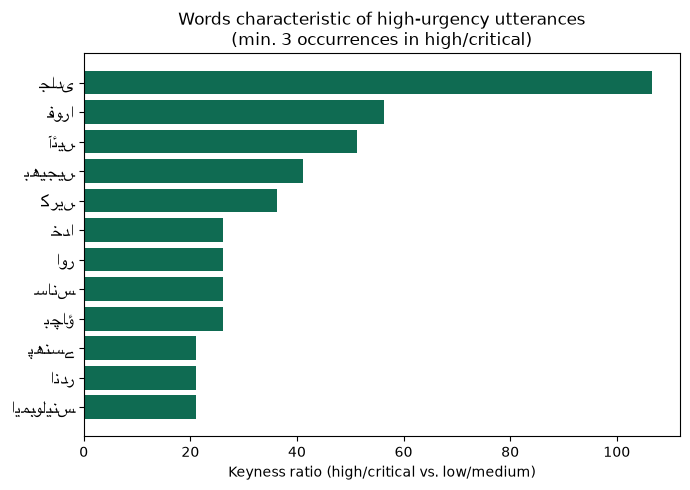

In [4]:
shaped_labels = [shape_for_display(w) for w in top_key["word"][::-1]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(shaped_labels, top_key["keyness_ratio"][::-1], color="#0f6b52")
ax.set_yticklabels(shaped_labels, fontname="Geeza Pro", fontsize=13)
ax.set_xlabel("Keyness ratio (high/critical vs. low/medium)")
ax.set_title("Words characteristic of high-urgency utterances\n(min. 3 occurrences in high/critical)")
plt.tight_layout()
plt.savefig("../results/keyness_high_vs_low.png", dpi=150)
plt.show()

## Collocates of فوراً ("immediately") and جلدی ("quickly"/"hurry")

In [5]:
for node in ["فوراً", "جلدی"]:
    print(f"Collocates of '{node}' (window=3):")
    coll = collocates(df, node, window=3)
    for word, count in coll.most_common(8):
        print(f"  {word}: {count}")
    print()

Collocates of 'فوراً' (window=3):
  آئیں: 5
  ہے: 4
  بھیجیں: 4
  مدد: 2
  پلیز: 2
  خدا: 2
  کے: 2
  لیے: 2

Collocates of 'جلدی' (window=3):
  جلدی: 12
  آئیں: 9
  ہے: 7
  بھیجیں: 5
  ہیں: 5
  کریں: 4
  ایمبولینس: 3
  خدا: 3



## Discussion

The keyness comparison shows commands and distress-oriented vocabulary (e.g. `بھیجیں` "send", `آئیں` "come", distress markers) disproportionately associated with high/critical utterances, alongside the temporal-expression lexicon items themselves. Collocates of `فوراً` and `جلدی` cluster around imperative verbs (send, come) and, for `جلدی`, its own reduplicated form (`جلدی جلدی`) — consistent with the repetition pattern observed in `01_corpus_statistics.ipynb`.

This is descriptive corpus evidence at pilot scale (n=60), not a statistically validated finding — see `paper/research_report.md` for the full discussion and limitations.